In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_large.csv to ecommerce_customer_data_large.csv


In [ ]:
uploaded.keys()

dict_keys(['ecommerce_customer_data_large.csv'])

In [ ]:
import pandas as pd

df1 = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')
df2 = pd.read_csv('ecommerce_customer_data_large.csv')

In [ ]:
df1.head()
df1.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
df2.head()
df2.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
df1.info()
df1.isnull().sum()
df1.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


np.int64(0)

In [ ]:
df = df1.copy()

df.drop_duplicates(inplace=True)

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['age_group'] = pd.cut(
    df['Customer Age'],
    bins=[18,25,35,45,60,100],
    labels=['18-25','26-35','36-45','46-60','60+']
)

df['order_value_group'] = pd.cut(
    df['Total Purchase Amount'],
    bins=[0,100,500,1000,5000],
    labels=['Low','Medium','High','Very High']
)

In [ ]:
df['Returns'] = df['Returns'].fillna(0)

In [ ]:
return_rate = (df['Returns'].sum() / len(df)) * 100
print("Return Rate:", round(return_rate, 2), "%")

Return Rate: 40.31 %


In [ ]:
category_return_rate = df.groupby('Product Category')['Returns'].mean() * 100
print(category_return_rate.sort_values(ascending=False))

Product Category
Home           40.414435
Electronics    40.392548
Books          40.352680
Clothing       40.134840
Name: Returns, dtype: float64


In [ ]:
payment_return_rate = df.groupby('Payment Method')['Returns'].mean() * 100
print(payment_return_rate.sort_values(ascending=False))

Payment Method
Cash           40.592055
PayPal         40.332990
Credit Card    40.329001
Crypto         39.571480
Name: Returns, dtype: float64


In [ ]:
gender_return_rate = df.groupby('Gender')['Returns'].mean() * 100
print(gender_return_rate)

Gender
Female    40.308219
Male      40.306975
Name: Returns, dtype: float64


In [ ]:
age_return_rate = df.groupby('age_group')['Returns'].mean() * 100
print(age_return_rate)

age_group
18-25    40.634559
26-35    40.173965
36-45    40.384860
46-60    40.152226
60+      40.366837
Name: Returns, dtype: float64


/tmp/ipykernel_973/159381548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_return_rate = df.groupby('age_group')['Returns'].mean() * 100


In [ ]:
monthly_returns = df.groupby(df['Purchase Date'].dt.month)['Returns'].sum()
print(monthly_returns)

Purchase Date
1     9115.0
2     8378.0
3     9244.0
4     8955.0
5     9355.0
6     8992.0
7     9334.0
8     9286.0
9     7705.0
10    6793.0
11    6726.0
12    6886.0
Name: Returns, dtype: float64


In [ ]:
value_group_return_rate = df.groupby('order_value_group')['Returns'].mean() * 100
print(value_group_return_rate)

order_value_group
Low           0.000000
Medium       39.760559
High         39.996812
Very High    40.377247
Name: Returns, dtype: float64


/tmp/ipykernel_973/2601718496.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  value_group_return_rate = df.groupby('order_value_group')['Returns'].mean() * 100


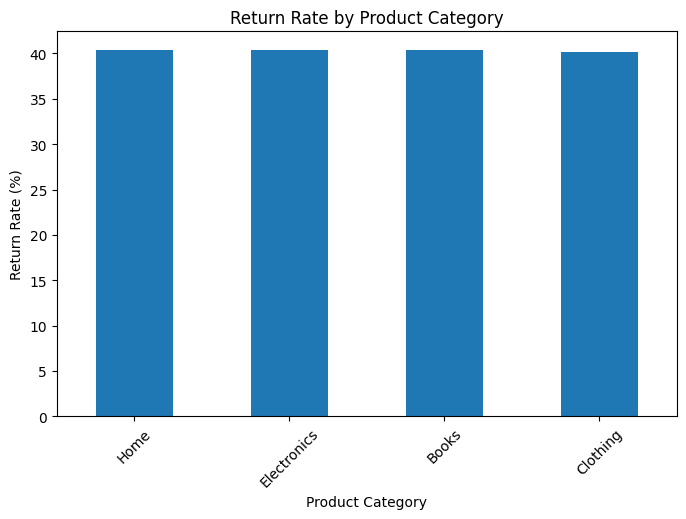

In [ ]:
category_return_rate.sort_values(ascending=False).plot(kind='bar', figsize=(8,5))
plt.title('Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.show()

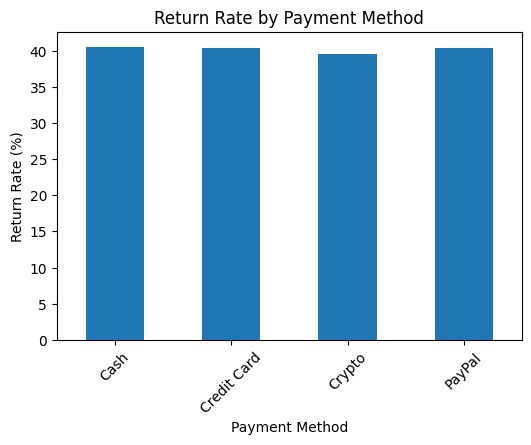

In [ ]:
payment_return_rate.plot(kind='bar', figsize=(6,4))
plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.show()

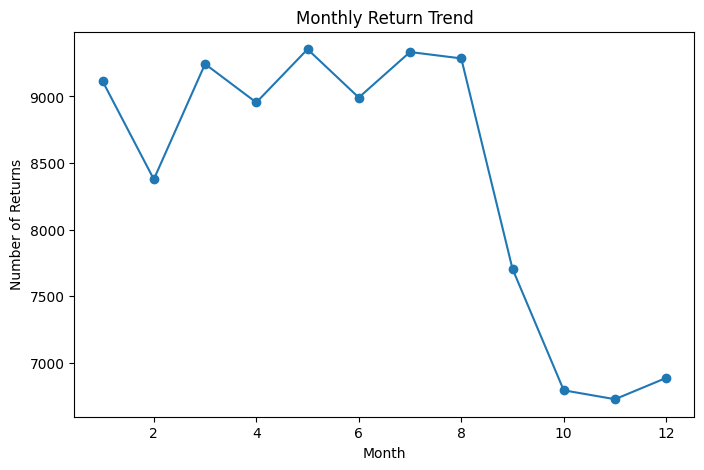

In [ ]:
monthly_returns.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Monthly Return Trend')
plt.xlabel('Month')
plt.ylabel('Number of Returns')
plt.show()

In [ ]:
df.to_csv('cleaned_ecommerce_returns.csv', index=False)

In [ ]:
from google.colab import files
files.download('cleaned_ecommerce_returns.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>